# Indian Railway Delay Prediction — EDA, Preprocessing & Feature Engineering

**Input:** one CSV dataset (`IR_regression_dataset.csv`)  
**Target:** `delay_minutes`

This notebook is designed to run in **Google Colab or Jupyter Notebook**.

- Uses **one dataset only**.
- Creates the required **80:20 train/test split internally**.
- Fits preprocessing **only on the training data** to avoid data leakage.
- Handles missing values, duplicate rows, categorical variables, and engineered features.
- Saves processed data and the fitted preprocessing object for the regression/classification notebooks.


In [1]:
# 1. Import libraries and set configuration

import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
DEFAULT_DATA_FILE = "IR_regression_dataset.csv"
OUTPUT_DIR = "regression_artifacts"

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")
print("Python version:", sys.version.split()[0])
print("Pandas version:", pd.__version__)
print("Random state:", RANDOM_STATE)
print("Output folder:", OUTPUT_DIR)


Libraries imported successfully.
Python version: 3.13.9
Pandas version: 2.3.3
Random state: 42
Output folder: regression_artifacts


In [38]:
# 2. Select the dataset

import os
import pandas as pd

DATA_FILE = r"C:\Users\saisi\OneDrive\Attachments\Documents\Desktop\ML_REVIEW\data\IR_regression_dataset.csv"

if not os.path.isfile(DATA_FILE):
    raise FileNotFoundError(
        f"Dataset not found at:\n{DATA_FILE}"
    )

print("Dataset path verified:")
print(os.path.abspath(DATA_FILE))

train_df = pd.read_csv(DATA_FILE)

print("\nDataset loaded successfully!")
print("Dataset shape:", train_df.shape)

display(train_df.head())

Dataset path verified:
C:\Users\saisi\OneDrive\Attachments\Documents\Desktop\ML_REVIEW\data\IR_regression_dataset.csv

Dataset loaded successfully!
Dataset shape: (100000, 44)


,journey_id,train_number,train_type,departure_date,year,month,day_of_week,departure_hour,is_weekend,is_night_departure,...,has_lhb_coaches,is_rake_shared,maintenance_score,seat_utilisation_pct,is_overloaded,late_incoming_rake,is_special_train,route_historical_ontime_pct,primary_delay_cause,delay_minutes
0,IR00554899,11603,Mail/Express,2023-05-18,2023,5,3,5,0,0,...,0,0,7.0,65.4,0,0,0,64.2,Track Congestion,159
1,IR00834822,12927,Garib Rath Express,2022-10-27,2022,10,3,18,0,0,...,0,1,7.7,73.4,0,0,1,59.7,Track Congestion,138
2,IR01010498,11362,Mail/Express,2020-06-29,2020,6,0,5,0,0,...,1,1,5.7,50.8,0,0,0,85.7,Track Maintenance / PSR,95
3,IR01611367,22614,Vande Bharat Express,2020-02-20,2020,2,3,7,0,0,...,0,0,4.7,67.1,0,0,0,73.0,On Time,7
4,IR01167733,12381,Jan Shatabdi Express,2019-11-22,2019,11,4,16,0,0,...,0,0,10.0,73.2,0,0,1,49.9,Unscheduled Halt,109


In [9]:
# 3. Load the single dataset

df = pd.read_csv(DATA_FILE)

if df.empty:
    raise ValueError("The CSV was loaded, but it contains no rows.")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head())


Dataset loaded successfully!
Number of rows: 100000
Number of columns: 44


,journey_id,train_number,train_type,departure_date,year,month,day_of_week,departure_hour,is_weekend,is_night_departure,...,has_lhb_coaches,is_rake_shared,maintenance_score,seat_utilisation_pct,is_overloaded,late_incoming_rake,is_special_train,route_historical_ontime_pct,primary_delay_cause,delay_minutes
0,IR00554899,11603,Mail/Express,2023-05-18,2023,5,3,5,0,0,...,0,0,7.0,65.4,0,0,0,64.2,Track Congestion,159
1,IR00834822,12927,Garib Rath Express,2022-10-27,2022,10,3,18,0,0,...,0,1,7.7,73.4,0,0,1,59.7,Track Congestion,138
2,IR01010498,11362,Mail/Express,2020-06-29,2020,6,0,5,0,0,...,1,1,5.7,50.8,0,0,0,85.7,Track Maintenance / PSR,95
3,IR01611367,22614,Vande Bharat Express,2020-02-20,2020,2,3,7,0,0,...,0,0,4.7,67.1,0,0,0,73.0,On Time,7
4,IR01167733,12381,Jan Shatabdi Express,2019-11-22,2019,11,4,16,0,0,...,0,0,10.0,73.2,0,0,1,49.9,Unscheduled Halt,109


In [10]:
# 4. Standardise column names

df.columns = (
    df.columns.astype(str)
      .str.strip()
      .str.lower()
      .str.replace(r"[^a-z0-9_]+", "_", regex=True)
      .str.replace(r"_+", "_", regex=True)
      .str.strip("_")
)

print("Standardised columns:")
print(df.columns.tolist())

TARGET = "delay_minutes"

if TARGET not in df.columns:
    raise KeyError(
        f"Target column '{TARGET}' was not found after column-name standardisation. "
        f"Available columns are: {df.columns.tolist()}"
    )


Standardised columns:
['journey_id', 'train_number', 'train_type', 'departure_date', 'year', 'month', 'day_of_week', 'departure_hour', 'is_weekend', 'is_night_departure', 'is_peak_hour', 'is_festival_season', 'season', 'zone', 'zone_abbr', 'source_station_category', 'destination_station_category', 'distance_km', 'num_scheduled_stops', 'scheduled_travel_hours', 'track_doubled', 'is_hdn_route', 'traction_type', 'is_electrified', 'psr_count', 'is_circular_route', 'is_monsoon_season', 'is_fog_risk', 'fog_risk_score', 'zone_fog_index', 'zone_congestion_index', 'season_severity_score', 'loco_age_years', 'coach_age_years', 'has_lhb_coaches', 'is_rake_shared', 'maintenance_score', 'seat_utilisation_pct', 'is_overloaded', 'late_incoming_rake', 'is_special_train', 'route_historical_ontime_pct', 'primary_delay_cause', 'delay_minutes']


## Section A — Exploratory Data Analysis

In [11]:
# 5. Basic dataset audit

print("Shape:", df.shape)

print("\nData types:")
display(df.dtypes.to_frame("Data_Type"))

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("Missing_Count"))

print("\nDuplicate rows:", int(df.duplicated().sum()))

print("\nTarget column:", TARGET)
print("Target missing values:", int(df[TARGET].isna().sum()))


Shape: (100000, 44)

Data types:


,Data_Type
journey_id,object
train_number,int64
train_type,object
departure_date,object
year,int64
month,int64
day_of_week,int64
departure_hour,int64
is_weekend,int64
is_night_departure,int64



Missing values:


,Missing_Count
journey_id,0
train_number,0
psr_count,0
is_circular_route,0
is_monsoon_season,0
is_fog_risk,0
fog_risk_score,0
zone_fog_index,0
zone_congestion_index,0
season_severity_score,0



Duplicate rows: 0

Target column: delay_minutes
Target missing values: 0


Target statistics:


count    100000.000000
mean         97.722800
std          66.025353
min           0.000000
25%          13.000000
50%         110.000000
75%         140.000000
max         503.000000
Name: delay_minutes, dtype: float64

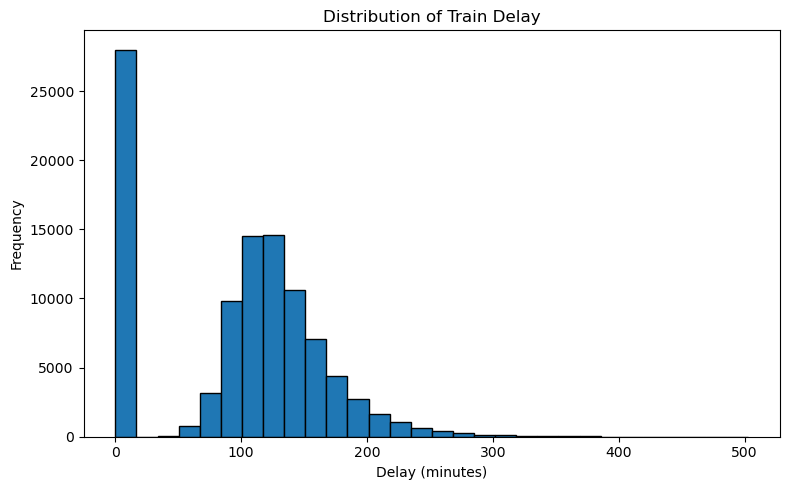

In [12]:
# 6. Target distribution

print("Target statistics:")
display(df[TARGET].describe())

plt.figure(figsize=(8, 5))
plt.hist(df[TARGET].dropna(), bins=30, edgecolor="black")
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Train Delay")
plt.tight_layout()
plt.show()
plt.close()


Number of numerical predictor features: 33


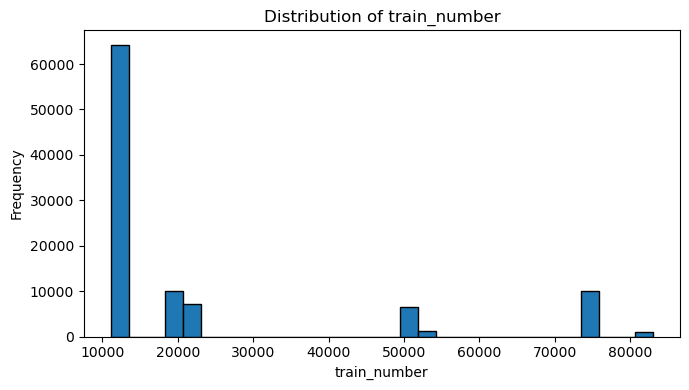

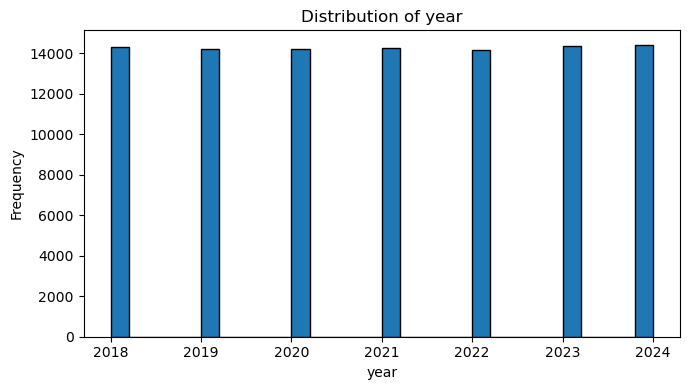

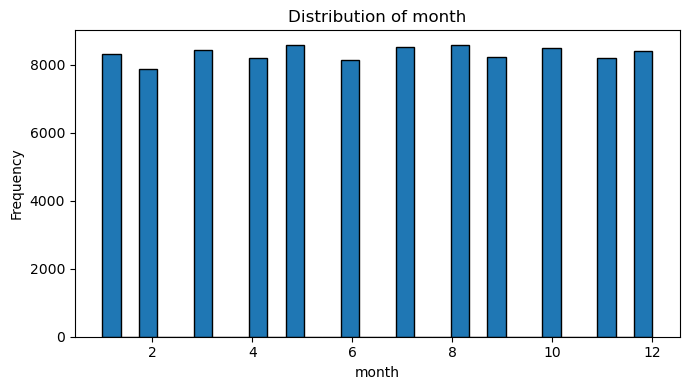

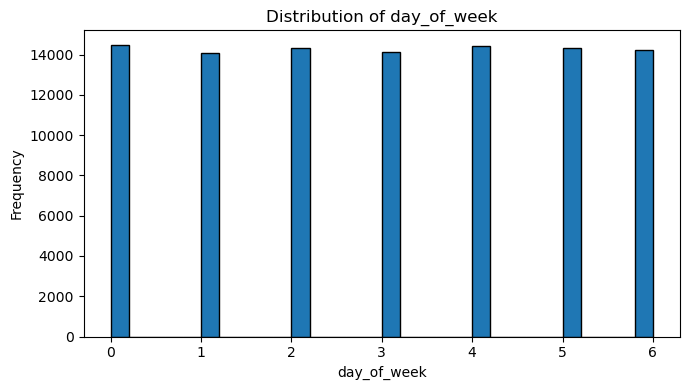

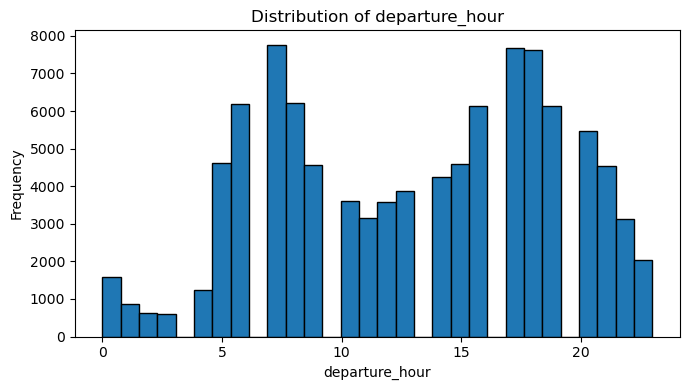

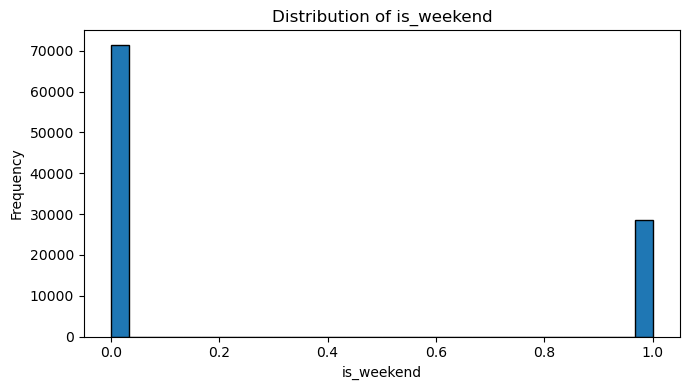

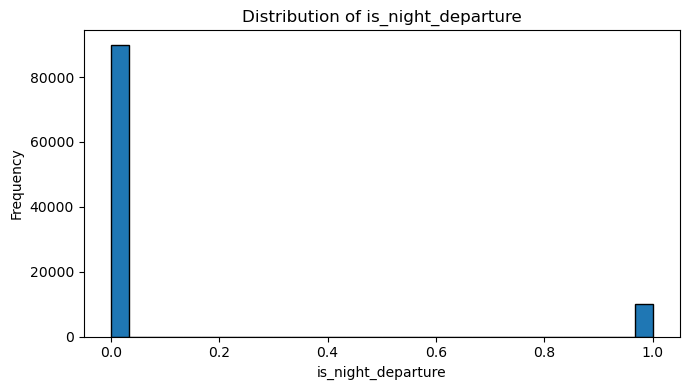

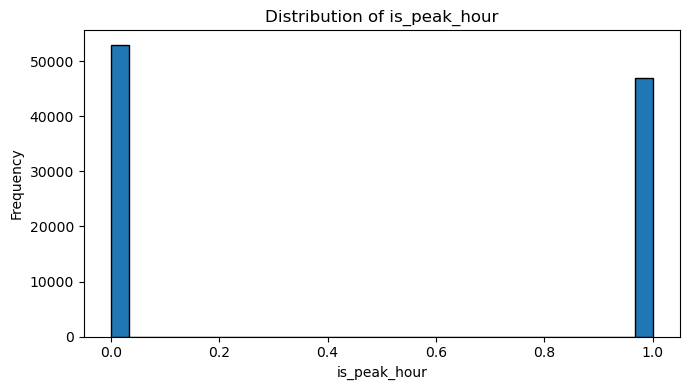

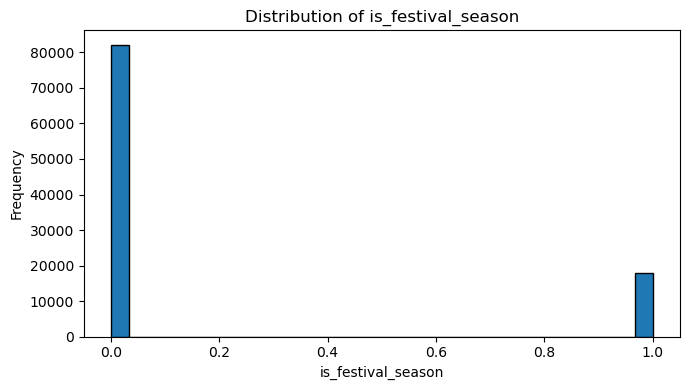

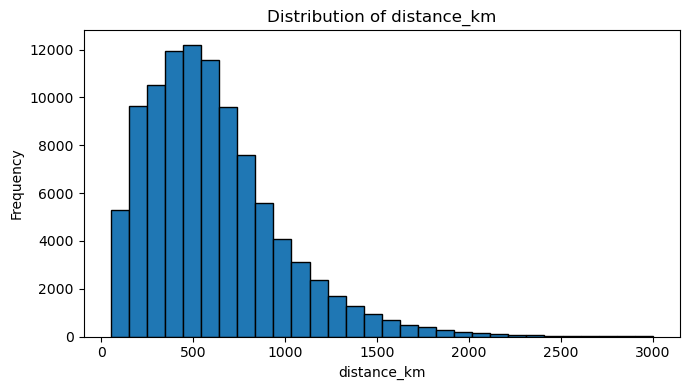

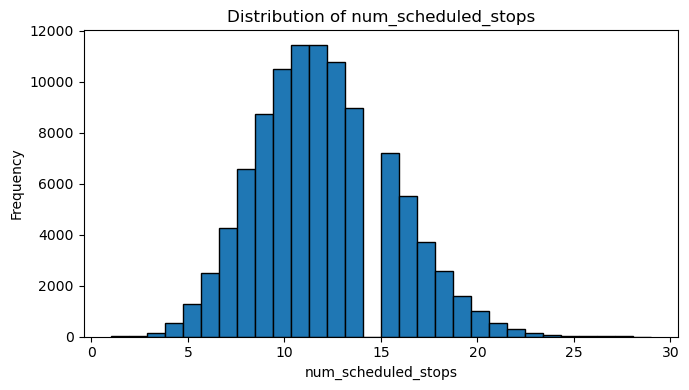

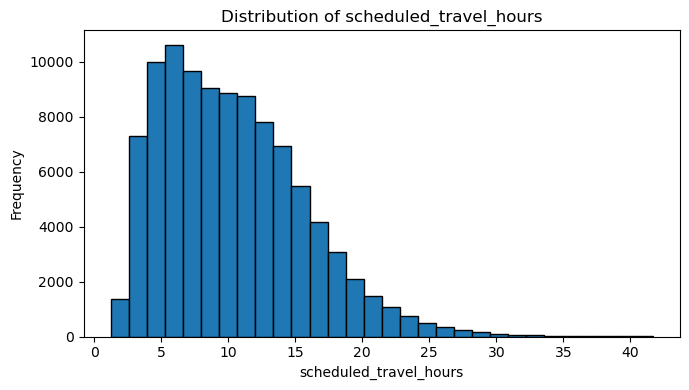

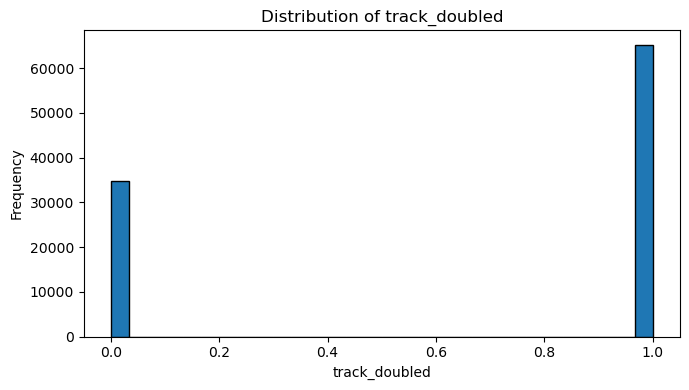

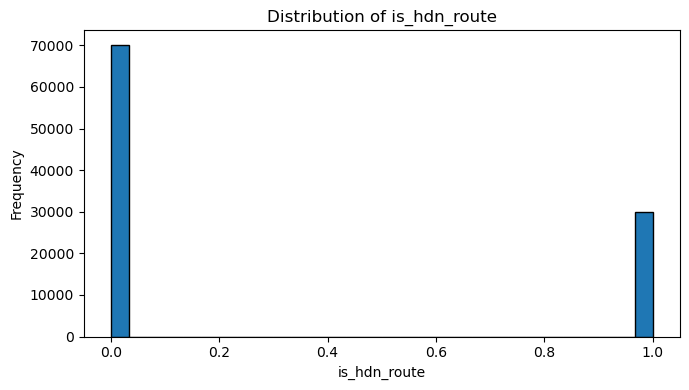

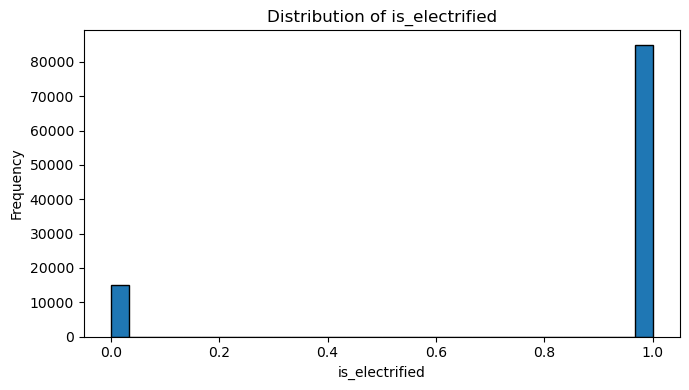

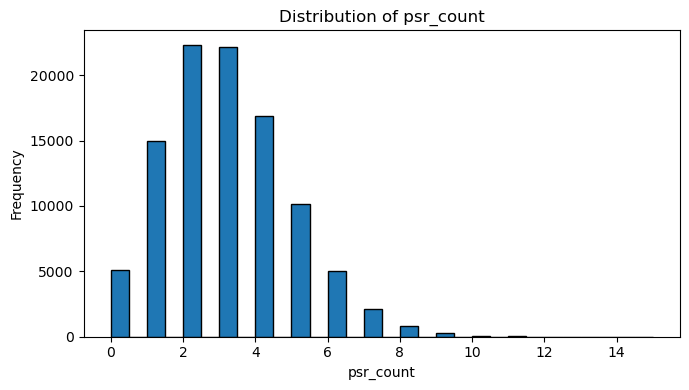

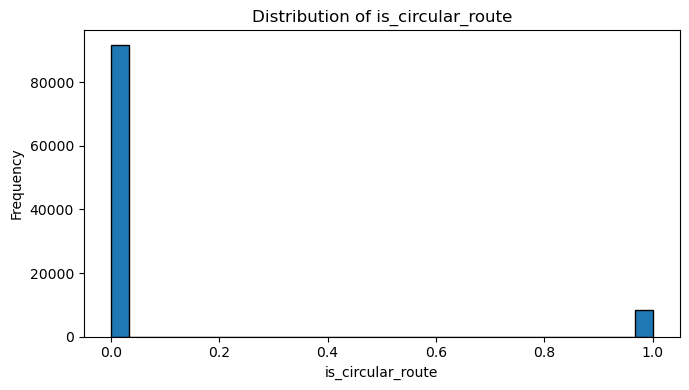

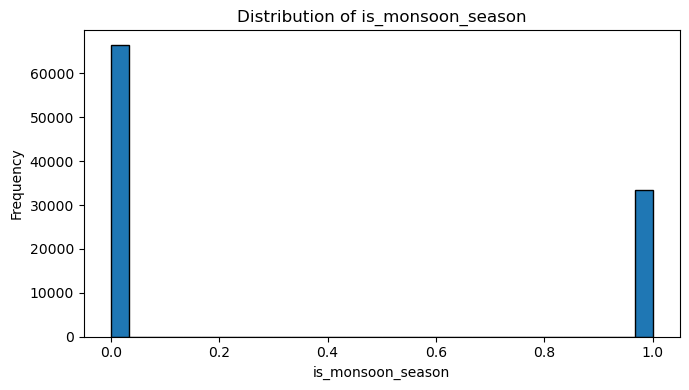

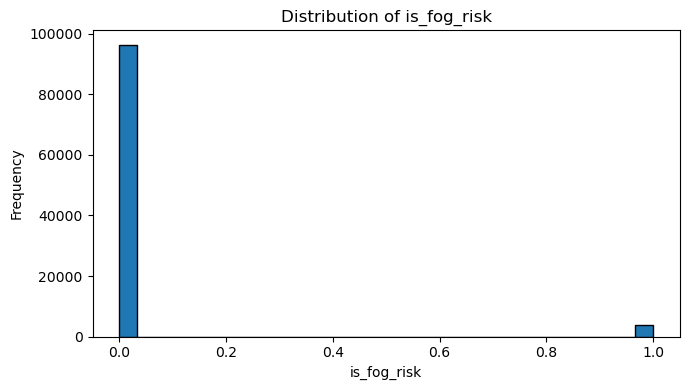

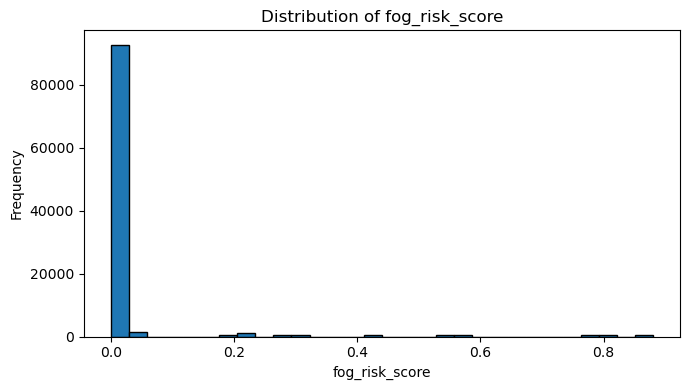

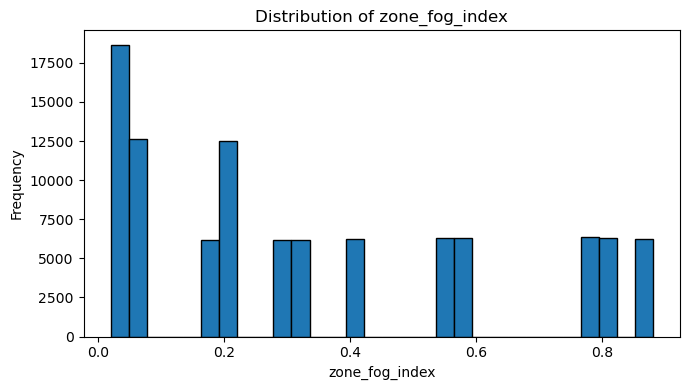

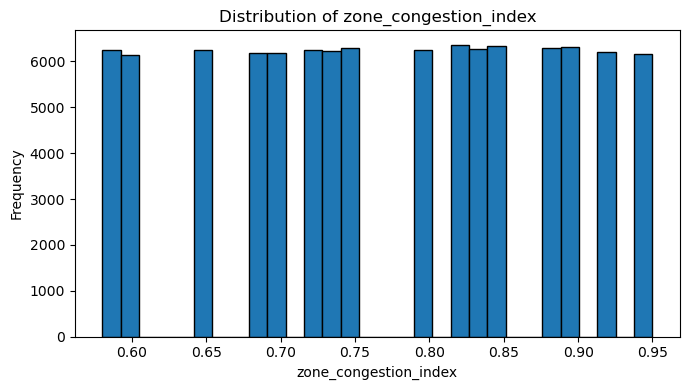

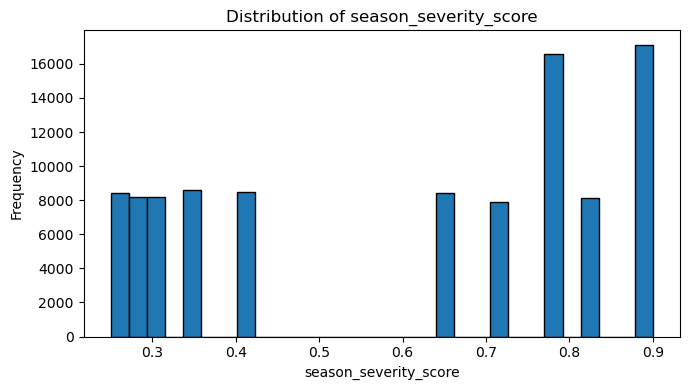

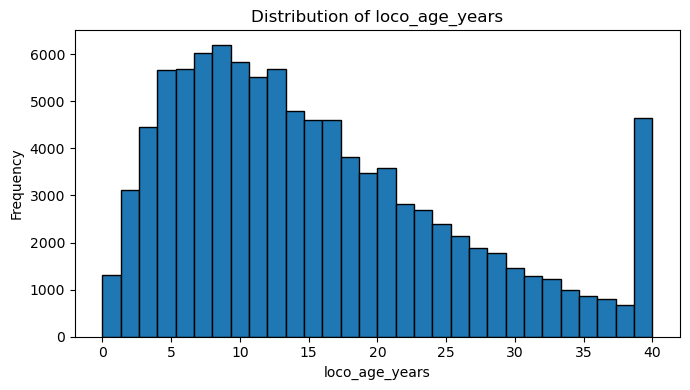

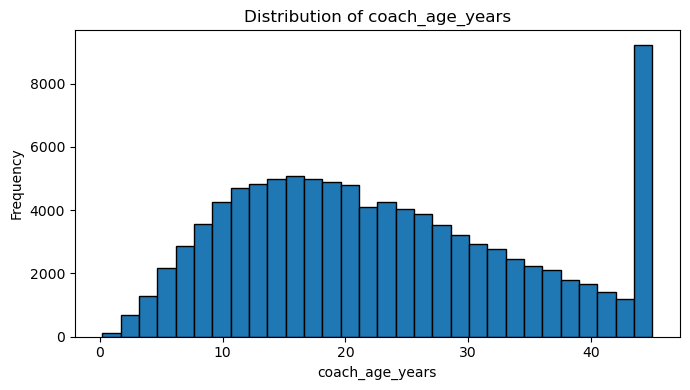

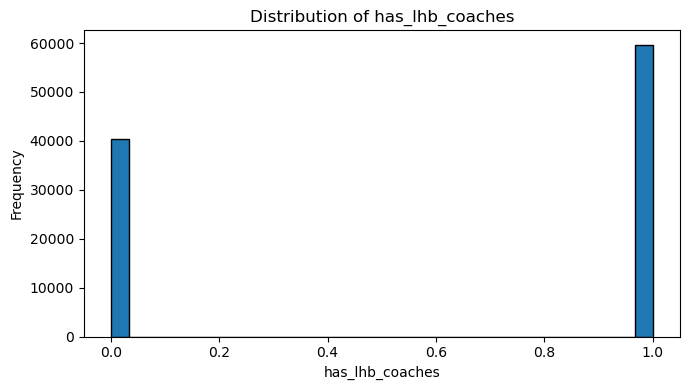

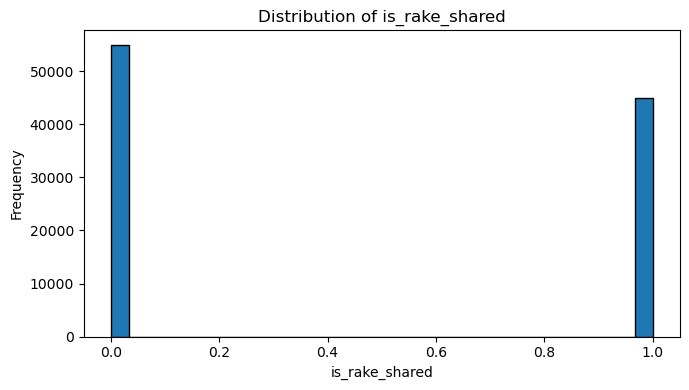

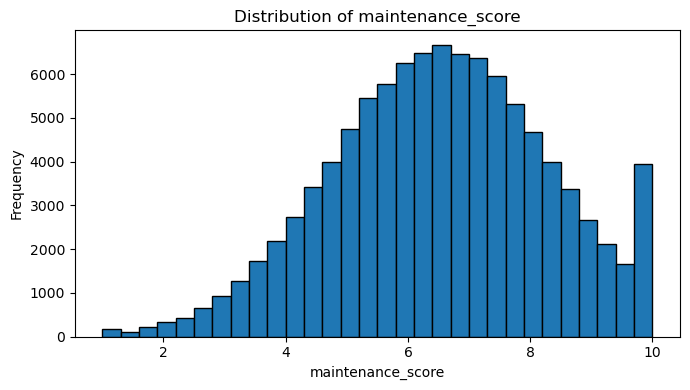

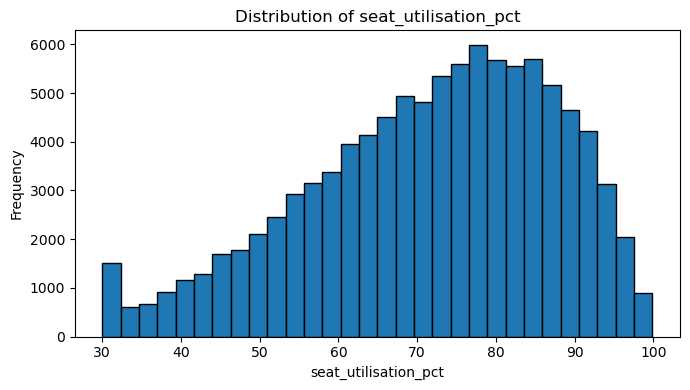

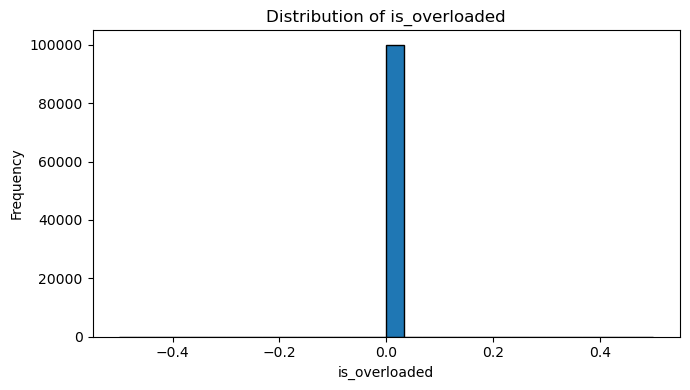

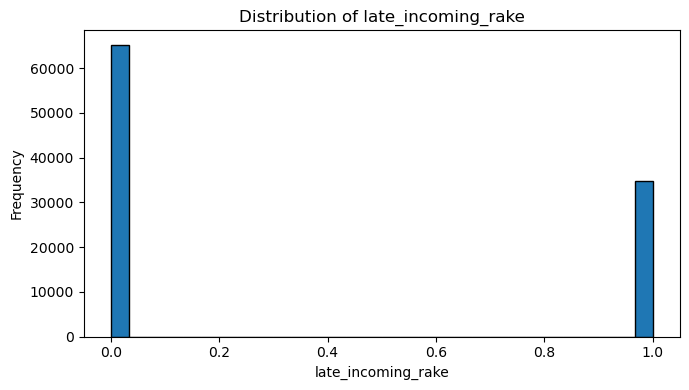

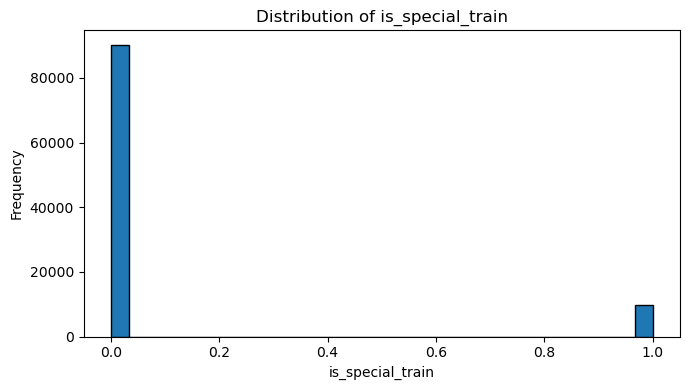

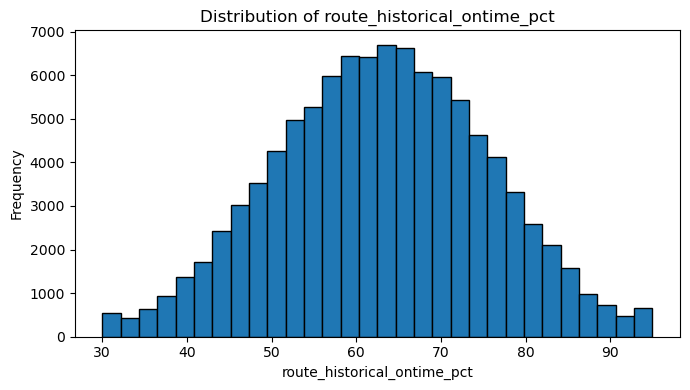

In [13]:
# 7. Numerical feature distributions

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_features = [c for c in numeric_cols if c != TARGET]

if not numeric_features:
    raise ValueError("No numerical predictor columns were found.")

print("Number of numerical predictor features:", len(numeric_features))

for col in numeric_features:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=30, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
plt.close()


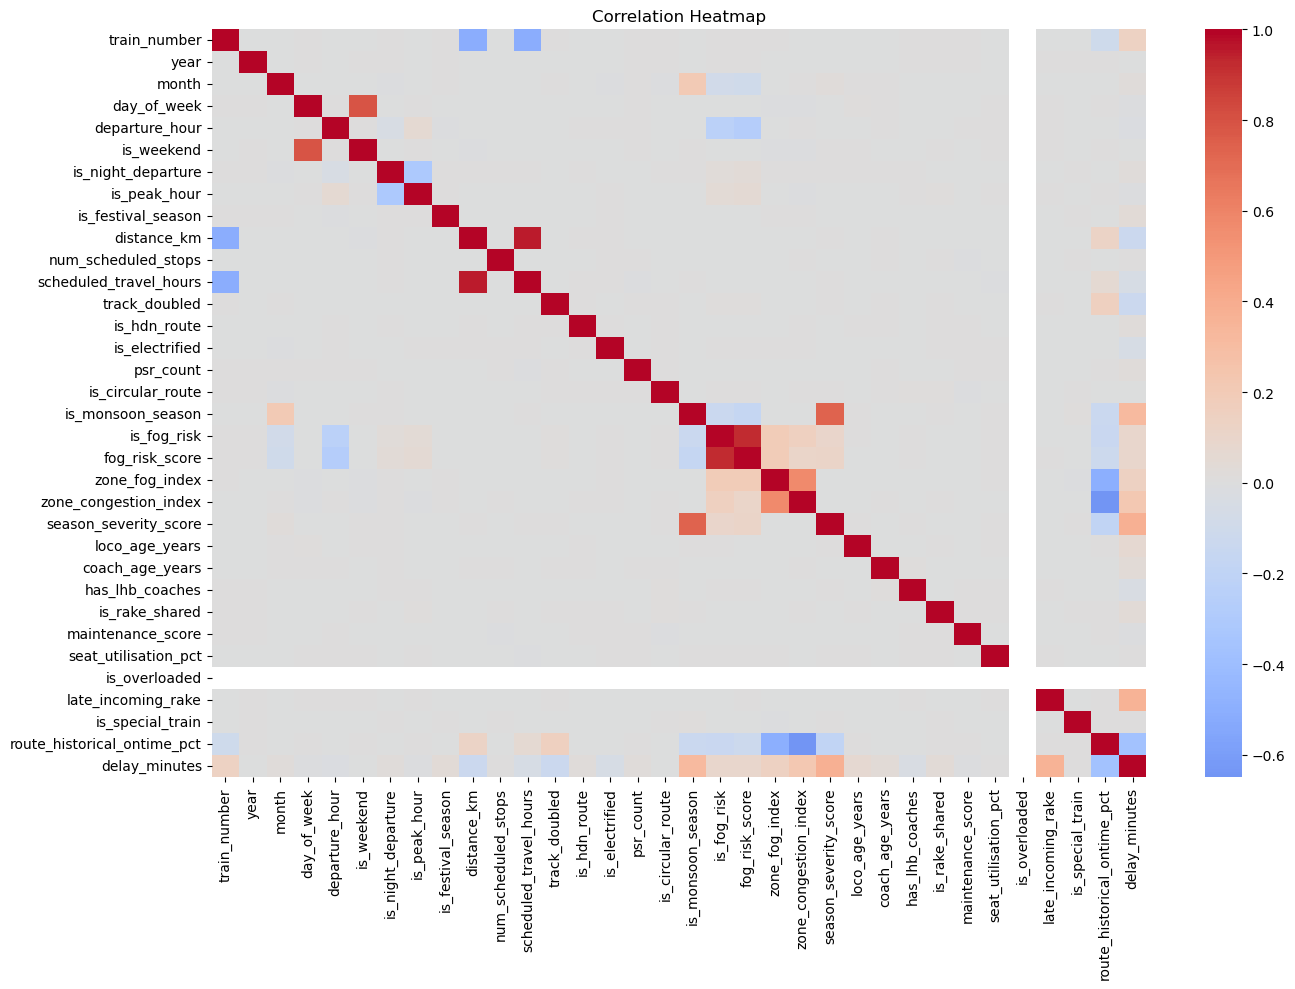

In [14]:
# 8. Correlation heatmap

corr = df[numeric_cols].corr(numeric_only=True)

if corr.empty:
    raise ValueError("A numerical correlation matrix could not be created.")

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
plt.close()


Features selected for scatter plots: ['season_severity_score', 'route_historical_ontime_pct']


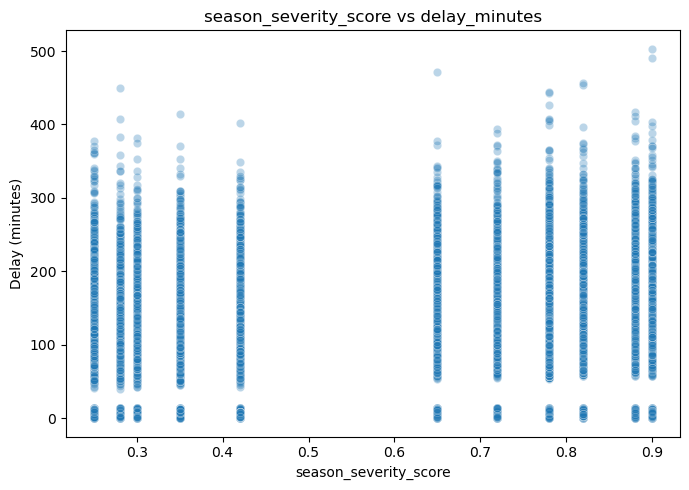

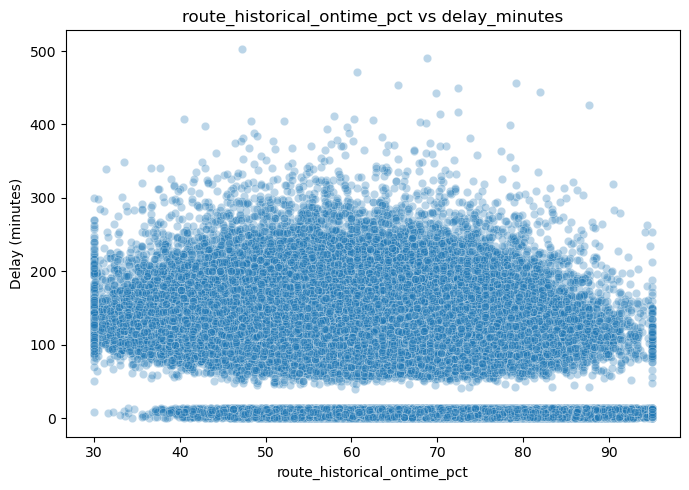

In [15]:
# 9. Two feature-target scatter plots

valid_numeric_features = [
    c for c in numeric_features
    if df[c].notna().any() and df[c].nunique(dropna=True) > 1
]

if not valid_numeric_features:
    raise ValueError("There are not enough valid numerical features for scatter plots.")

target_corr = (
    df[valid_numeric_features + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .abs()
    .dropna()
    .sort_values(ascending=False)
)

top_two = target_corr.head(2).index.tolist()

# If fewer than two usable features exist, use whatever is available.
print("Features selected for scatter plots:", top_two)

for col in top_two:
    plot_df = df[[col, TARGET]].dropna()

    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=plot_df, x=col, y=TARGET, alpha=0.3)
    plt.title(f"{col} vs {TARGET}")
    plt.xlabel(col)
    plt.ylabel("Delay (minutes)")
    plt.tight_layout()
    plt.show()
plt.close()


### EDA observations

Review the generated plots and write the team's observations here before submission. Do not copy the example wording blindly; the observations should reflect the actual dataset and plots.

In [18]:
# 12. Feature engineering

required_engineering_columns = [
    "num_scheduled_stops",
    "distance_km",
    "loco_age_years",
    "coach_age_years",
    "seat_utilisation_pct",
    "is_overloaded",
    "fog_risk_score",
    "is_monsoon_season",
    "scheduled_travel_hours"
]

missing_engineering_columns = [
    c for c in required_engineering_columns if c not in df.columns
]

if missing_engineering_columns:
    raise KeyError(
        "The dataset is missing columns required for the planned feature engineering: "
        + ", ".join(missing_engineering_columns)
    )

# Replace zero denominators with NaN. The numerical imputer later handles these
# engineered missing values using training-set medians.
df["stops_per_100km"] = (
    df["num_scheduled_stops"] /
    df["distance_km"].replace(0, np.nan)
) * 100

df["avg_rolling_stock_age"] = (
    df["loco_age_years"] + df["coach_age_years"]
) / 2

df["operational_stress"] = (
    df["seat_utilisation_pct"] * (1 + df["is_overloaded"])
)

df["weather_risk"] = (
    df["fog_risk_score"] * (1 + df["is_monsoon_season"])
)

df["route_efficiency"] = (
    df["distance_km"] /
    df["scheduled_travel_hours"].replace(0, np.nan)
)

new_features = [
    "stops_per_100km",
    "avg_rolling_stock_age",
    "operational_stress",
    "weather_risk",
    "route_efficiency"
]

print("Feature engineering completed.")
print("New features:", new_features)

display(df[new_features].describe())


Feature engineering completed.
New features: ['stops_per_100km', 'avg_rolling_stock_age', 'operational_stress', 'weather_risk', 'route_efficiency']


,stops_per_100km,avg_rolling_stock_age,operational_stress,weather_risk,route_efficiency
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2.974085,19.412811,71.522222,0.028758,57.650257
std,2.545325,7.726570,15.769879,0.126724,13.282176
min,0.112486,1.200000,30.000000,0.000000,37.931034
25%,1.392111,13.550000,61.100000,0.000000,51.989563
50%,2.161383,18.750000,73.700000,0.000000,54.993160
75%,3.561644,24.750000,83.900000,0.000000,62.001505
max,42.307692,42.500000,99.900000,0.880000,95.215311
